In [17]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

In [12]:
iris = load_iris()

df = pd.DataFrame(iris.data,columns=iris.feature_names)
df['target'] = iris.target

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [13]:
x = df[['petal length (cm)','petal width (cm)']]
y = df['target']

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [18]:
scaler = StandardScaler()
x_train_scaler = scaler.fit_transform(x_train)
x_test_scaler = scaler.transform(x_test)

In [19]:
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

In [22]:
model = KNeighborsClassifier()
model.fit(x_train_scaler,y_train_enc)

KNeighborsClassifier()

In [23]:
y_pred = model.predict(x_test_scaler)

In [27]:
accuracy = accuracy_score(y_test_enc,y_pred)
cof = confusion_matrix(y_test_enc,y_pred)
report = classification_report(y_test_enc,y_pred)

print(f"KNN Classifier Accuracy: {accuracy*100}%\n Confusion Matrix:\n {cof}\n Classification Report: {report}")

KNN Classifier Accuracy: 95.55555555555556%
 Confusion Matrix:
 [[19  0  0]
 [ 0  9  1]
 [ 0  1 15]]
 Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.90      0.90      0.90        10
           2       0.94      0.94      0.94        16

    accuracy                           0.96        45
   macro avg       0.95      0.95      0.95        45
weighted avg       0.96      0.96      0.96        45



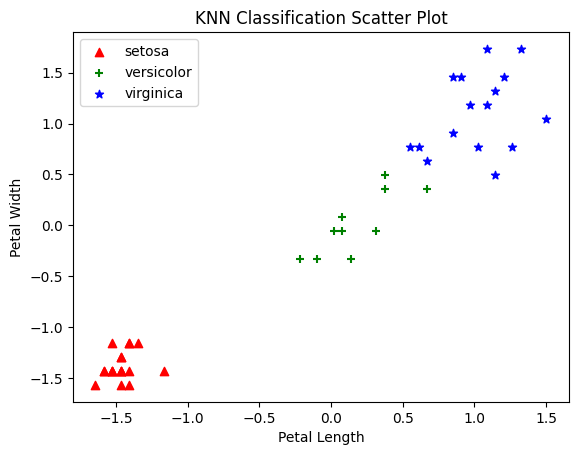

In [33]:
labels = iris.target_names
colors = ['r','g','b']
markers = ['^','+','*']

for i,label in enumerate(labels):
    class_points = (y_pred == i)
    plt.scatter(x_test_scaler[class_points,0],x_test_scaler[class_points,1],marker=markers[i],color=colors[i],label = f"{label}")
    plt.title("KNN Classification Scatter Plot")
    plt.legend()
    plt.xlabel("Petal Length")
    plt.ylabel("Petal Width")
